# FFT Survival Kit: Reading Signals in the Frequency Domain
#### From sampled records $x[n]$ to magnitude spectra $|\mathbf{X}[k]|$
* Why do we need the frequency domain?
* What data does the FFT actually see?
* From $x[n]$ to $\mathbf{X}[k]$
* Frequency bins: from $k$ to $f$ (hertz - Hz)
* Magnitude spectrum: what does a peak mean?
* Phase: important, but magnitude is often the first view
* Real signals are messier than sine waves
* What can go wrong with a single FFT?

## Weekly Learning Objectives
### By the end of this lesson, students will be able to:
1. **Describe** sampled records in terms of $x[n]$, $f_{s}$, $N$, and record duration.
2. **Explain** the DFT/FFT as a practical tool for transforming time-domain samples into frequency-domain bins.
3. **Convert** FFT bin indeces to frequency in hertz (Hz) $\Delta f= f_{s}/N$ and $f_{k}=kf_{s}/N$.
4. **Interpret** basic magnitudes spectra of sinusoidal, multi-tone, noise-like, and real audio/acoustic signals.
5. **Recognize** practical limitations of single-record FFT analysis and connect them to later topics such as windowing, resolution, averaging, and PSD.

### Laboratory session
Given a sampled signal and its sampling rate, students should be able to compute and plot the FFT manitude spectrum, construct the correct frequency axis, identify dominant frequency components, and comment on basic limitations of the result.

## Why look at frequency?
A time waveform tells us how a signal changes with time. But for many audio and acoustic problems, we also want to know:
* What frequency content are present?
* Which components are strong or weak?
* Is the sinal tonal, harmonic, noisy, or broadband?
* How does the signal relate to what we hear or measure?

### Demo 1
A waveform is useful, but frequency content is not always obvious from the time plot.
* $x_{1}(t)=\sin{(2\pi 440 t)}$
* $x_{2}(t)=\sin{(2\pi 880 t)}$
* $x_{3}(t)=x_{1}(t)+0.5x_{2}(t)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

In [2]:
fs = 8000
N = 800
t = np.arange(N) / fs
x1 = np.sin(2*np.pi*440*t)
x2 = np.sin(2*np.pi*880*t)
x3 = x1 + 0.5*x2

In [3]:
def plot_3_signals_t():
    labels = ["$x_{1}(t)$","$x_{2}(t)$","$x_{3}(t)$"]
    fig,ax = plt.subplots(3,1)
    ax[0].plot(t[:200], x1[:200], label="440 Hz")
    ax[1].plot(t[:200], x2[:200], label="880 Hz")
    ax[2].plot(t[:200], x3[:200], label="440 + 880 Hz")
    ax[2].set_xlabel("Time (s)")
    ax[0].set_title("Time-domain waveforms")
    ax[0].set_xticklabels([])
    ax[1].set_xticklabels([])
    for i in range(3):
        ax[i].set_ylabel(labels[i])
        ax[i].set_xlim(0,0.025)
        ax[i].set_ylim(-2,2)
        ax[i].grid(True)

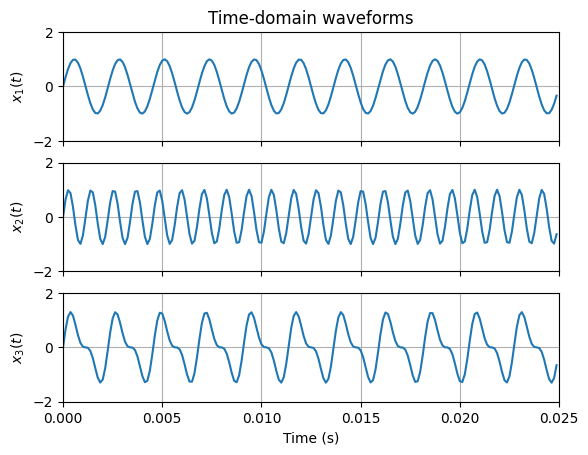

In [4]:
plot_3_signals_t()

### Frequency-domain view describes the signal differentlty
#### The same signals in the frequency domain

The spectrum (frequency-domain view) is another description of the same signal. It shows how strongly each signal is related to sinusoidal patterns at different frequencies.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fs = 8000
N = 800
t = np.arange(N) / fs

x1 = np.sin(2*np.pi*440*t)
x2 = np.sin(2*np.pi*880*t)
x3 = x1 + 0.5*x2

def mag_spectrum(x, fs):
    N = len(x)
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, d=1/fs)
    mag = np.abs(X) / N
    return f, mag

f, X1mag = mag_spectrum(x1, fs)
_, X2mag = mag_spectrum(x2, fs)
_, X3mag = mag_spectrum(x3, fs)

def plot_3_signals_f():
    labels = ["$|\\mathbf{X}_{1}(f)|$","$|\\mathbf{X}_{2}(f)|$","$|\\mathbf{X}_{3}(f)|$"]
    fig, ax = plt.subplots(3,1)
    ax[0].plot(f, X1mag*2, label="440 Hz")
    ax[1].plot(f, X2mag*2, label="880 Hz")
    ax[2].plot(f, X3mag*2, label="440 + 880 Hz")
    ax[2].set_xlabel("Frequency (Hz)")
    ax[0].set_xticklabels([])
    ax[1].set_xticklabels([])
    for i in range(3):
        ax[i].set_xlim(0, 1500)
        ax[i].set_ylim(0,1.5)
        ax[i].set_ylabel(labels[i])
        ax[i].grid(True)
    ax[0].set_title("Magnitude spectra")
    fig.tight_layout()
#fig.savefig("figures/magnitude_spectra_440_880.png", dpi=160)
#plt.close(fig)

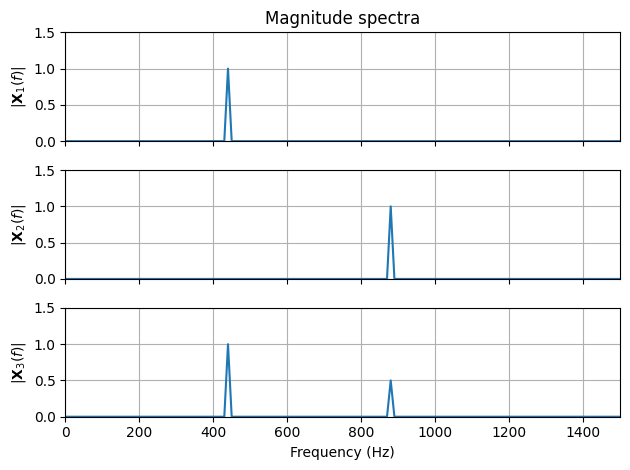

In [6]:
plot_3_signals_f()

### Time-domain and frequency-domain views

| View | Main question | Example use |
|---|---|---|
| Time domain | How does the signal change over time? | waveform, transient, envelope |
| Frequency domain | How is the signal distributed across frequency? | tone-like behavior, harmonics, noise, spectrum |

Both views describe the same signal, but emphasize different properties.

### Why this matters in audio and acoustics

Frequency-domain analysis helps us study:

- pitch and harmonics in musical sounds
- tonal noise and broadband noise
- filter and equalizer behavior
- room and system responses
- measurement reliability in noisy environments

### Key message

Time-domain and frequency-domain views describe the same signal from different perspectives.

Time domain: how the signal changes over time.

Frequency domain: how the signal is distributed across frequency.

For DSP practice, we need both views.

## What data does the FFT actually see?

The FFT does not analyze the entire continuous signal.

It analyze a finite sampled record:

\\[
x[0], x[1], x[2], \ldots, x[N-1]
\\]

This is usually denoted by $x[n]$ which is defined as:
\\[
x[n] \equiv x(nT_{s})
\\]
where $T_{s}=1/f_{s}$.

- $T_{s}$ : Sampling period (second)
- $f_{s}$ : Sampling frequency (Hertz)

In [7]:
def plot_sampled_signal(f=1,fs=20):
    t = np.arange(1000)*(1/1000)
    xc = np.sin(2*np.pi*f*t)
    fig,ax = plt.subplots(2,1)
    ax[0].plot(t,xc,'--')
    n = np.arange(fs)*(1/fs)
    xn = np.sin(2*np.pi*f*n)
    ax[0].plot(n,xn,'C0o')
    ax[1].stem(xn)
    ax[0].set_xlim(0,1)
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("x(t)")
    ax[1].set_xlim(0,len(xn))
    ax[1].set_xlabel("Index (n)")
    ax[1].set_ylabel("x[n]")
    for i in range(2):
        ax[i].set_ylim(-1.5,1.5)
        ax[i].grid(True)
    fig.tight_layout()

In [23]:
interact(plot_sampled_signal,f = IntSlider(value=1,min=1,max=10,step=1,description="f"),fs = IntSlider(value=20,min=10,max=30,description="fs"));

interactive(children=(IntSlider(value=1, description='f', max=10, min=1), IntSlider(value=20, description='fs'…

#### To interpret the result, we must know
- the sample rate $f_{s}=1/T_{s}$
- the recorded length $N$
#### From continuous time to samples
A real audio or acoustic signal changes continuous in time. After sampling, we wrok with a **sequence** of numbers:
\\[
x[n] = x(nT_{s})
\\]
**n is not time but index** but we can translate it to time by $t=nT_{s}$

## From $x[n]$ to $\mathbf{X}[k]$ - DFT / FFT
* DFT stands for Discrete Fourier Transform.
* FFT stands for Fast Fourier Transform

The DFT transforms a finite sampled signal into a set of complex values:
\\[
\mathbf{X}[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N} \qquad k=0,1,\ldots,N-1
\\]
* $n$ : sample index
* $k$ : frequency-bin index
* $\mathbf{X}[k]$ : complex DFT sequence


The FFT is an efficient algorithm for computing the DFT. Usually software you use will do this for you.

## Frequency index - $k$
$k$ is not the actual frequency, but a frequency index. It can be translated to the actual frequency, **if and only if**, we know sampling frequency $f_{s}$, and number of data points in the processing frame $N$.

We can think that the resulting N-point DFT devides the frequency interval $[0,f_{s})$ into N interval, thus the frequency resolution is:
\\[
\Delta f = f_{s}/N.
\\]
Therefore, the actual frequency at the index $k$ is:
\\[
f_{k} = k\cdot \Delta f = k\cdot \frac{f_{s}}{N}
\\]

## Example
Given that, $f_{s}=8000$ Hz, $N=800$ points
* What is the frequency resolution of the DFT of this sequence?
* What is the actual frequency at $k=44$?

## Nyquist frequency
For a sampled signal with sampling rate ($f_s$), the highest distinct positive frequency is

\\[
f_\mathrm{Nyquist}=\frac{f_s}{2}
\\]

This $f_\mathrm{Nyquist}$ is called the nyquist frequency.

Frequency indices beyond (N/2) do not represent new positive frequencies. They represent the negative-frequency part of the DFT output.

In [9]:
import numpy as np

fs = 4
N = 8

n = np.arange(N)
x = np.cos(2 * np.pi * 1 * n / fs)

X = np.fft.fft(x)
f = np.fft.fftfreq(N, d=1/fs)
print("x =",np.array2string(x,precision=2,suppress_small=True))
print("X =",np.array2string(X,precision=2,suppress_small=True))

x = [ 1.  0. -1. -0.  1.  0. -1. -0.]
X = [-0.+0.j -0.+0.j  4.-0.j  0.+0.j  0.+0.j  0.+0.j  4.+0.j -0.+0.j]


In [10]:
print(" k    f_k (Hz)        X[k]")
print("-" * 36)

for k in range(N):
    print(f"{k:2d}    {f[k]:6.1f}      {X[k]:8.2f}")

 k    f_k (Hz)        X[k]
------------------------------------
 0       0.0      -0.00+0.00j
 1       0.5      -0.00+0.00j
 2       1.0      4.00-0.00j
 3       1.5      0.00+0.00j
 4      -2.0      0.00+0.00j
 5      -1.5      0.00+0.00j
 6      -1.0      4.00+0.00j
 7      -0.5      -0.00+0.00j


In [11]:
k = np.arange(N)
magnitude = np.abs(X) / N

In [12]:
def pltDFT(k,f,magnitude):
    fig, ax = plt.subplots(2, 1,figsize=(8, 4),constrained_layout=True)

    ax[0].stem(k, magnitude, basefmt=" ")
    ax[0].set_xticks(k)
    ax[0].set_xticklabels(k)
    ax[0].set_xlabel("Frequency index, $k$")
    ax[0].set_ylabel(r"$|X[k]|/N$")
    ax[0].set_title("DFT output indexed by $k$")
    ax[0].grid(True)

    ax[1].stem(k, magnitude, basefmt=" ")
    ax[1].set_xticks(k)
    ax[1].set_xticklabels([f"{fk:.1f}" for fk in f])
    ax[1].set_xlabel("Frequency, $f_k$ (Hz)")
    ax[1].set_ylabel(r"$|X[k]|/N$")
    ax[1].set_title("The same output labeled by frequency")
    ax[1].grid(True)

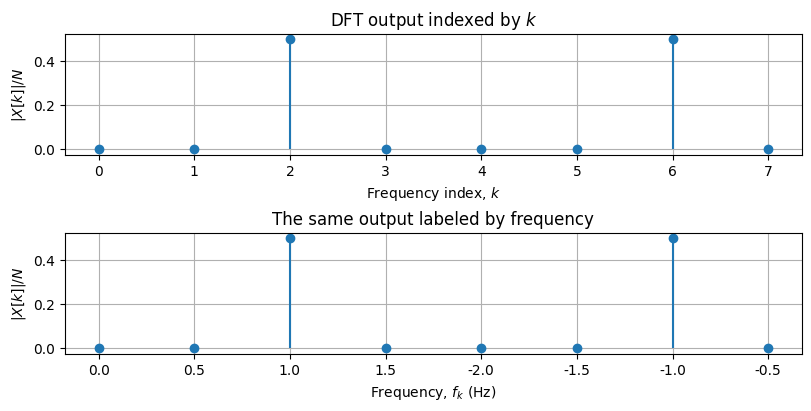

In [13]:
pltDFT(k,f,magnitude)

In [14]:
oneside_k = k[0:N//2 + 1]
oneside_f = oneside_k*fs/N
oneside_mag = magnitude[0:N//2 + 1]

print(oneside_k)
# You can also use
oneside_k = np.fft.rfftfreq(N,d=1/N)
oneside_f = np.fft.rfftfreq(N,d=1/fs)
oneside_mag = np.abs(np.fft.rfft(x))/N
print(oneside_k)
if (N/2 == N//2):
    oneside_mag[1:-2] = oneside_mag[1:-2]*2
else:
    oneside_mag[1:-1] = oneside_mag[1:-1]*2

[0 1 2 3 4]
[0. 1. 2. 3. 4.]


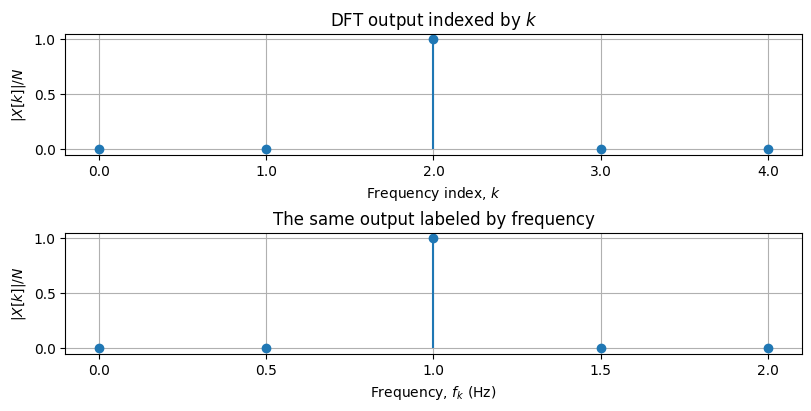

In [15]:
pltDFT(oneside_k,oneside_f,oneside_mag)

## Magitude and phase
Each DFT value in the sequence $\mathbf{X}[k]$ is generally a complex number.

It can be described by:
\\[
|\mathbf{X}[k]| \qquad \text{: Magnitude}
\\]

\\[
\angle\mathbf{X}[k] \qquad \text{: Phase}
\\]

In this lesson, we will mainly use the magnitude spectrum.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider


def plot_sine_spectrum(A=1.0, k=44, phi=0.0):
    fs = 8000
    N = 800
    delta_f = fs / N
    f0 = k * delta_f

    n = np.arange(N)
    t = n / fs
    x = A * np.cos(2 * np.pi * f0 * t + phi)

    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, d=1 / fs)

    # One-sided amplitude spectrum
    magnitude = np.abs(X) / N
    magnitude[1:-1] *= 2

    # Phase spectrum
    phase = np.angle(X)

    # Phase is meaningful only where the magnitude is non-negligible
    phase_visible = np.full_like(phase, np.nan)
    phase_visible[magnitude > 1e-6] = phase[magnitude > 1e-6]

    display_samples = int(0.02 * fs)

    fig, axes = plt.subplots(
        3, 1,
        figsize=(10, 7),
        constrained_layout=True
    )

    # Time-domain waveform
    axes[0].plot(t[:display_samples], x[:display_samples])
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_ylim(-2.2, 2.2)
    axes[0].set_title(
        rf"$x[n]={A:.1f}\cos(2\pi({f0:.1f})n/{fs}+{phi:.2f})$"
    )
    axes[0].grid(True)

    # Magnitude spectrum
    axes[1].stem(f, magnitude, basefmt=" ")
    axes[1].set_xlim(0, 1500)
    axes[1].set_ylim(0, 2.2)
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Magnitude")
    axes[1].set_title("One-sided magnitude spectrum")
    axes[1].grid(True)

    # Phase spectrum
    axes[2].stem(f, phase_visible, basefmt=" ")
    axes[2].set_xlim(0, 1500)
    axes[2].set_ylim(-np.pi, np.pi)
    axes[2].set_yticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
    )
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Phase (rad)")
    axes[2].set_title("Phase spectrum")
    axes[2].grid(True)

    plt.show()

In [17]:
interact(plot_sine_spectrum,
         A=FloatSlider(value=1.0,min=0.1,max=2.0,step=0.1,description="Amplitude"),
         k=IntSlider(value=44,min=1,max=150,step=1,description="Index k"),
         phi=FloatSlider(value=0.0,min=-np.pi,max=np.pi,step=np.pi / 12,description="Phase"));

interactive(children=(FloatSlider(value=1.0, description='Amplitude', max=2.0, min=0.1), IntSlider(value=44, d…

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from ipywidgets import interact, Dropdown
from IPython.display import Audio, display


def generate_signal(signal_type, t, rng):
    """Generate the selected signal at time instants t."""

    if signal_type == "Single tone":
        x = np.cos(2 * np.pi * 440 * t)

    elif signal_type == "Two tones":
        x = (
            np.cos(2 * np.pi * 440 * t)
            + 0.5 * np.cos(2 * np.pi * 880 * t)
        )

    elif signal_type == "Harmonic signal":
        x = (
            np.cos(2 * np.pi * 200 * t)
            + 0.5 * np.cos(2 * np.pi * 400 * t)
            + 0.25 * np.cos(2 * np.pi * 600 * t)
        )

    elif signal_type == "Tone + noise":
        x = (
            np.cos(2 * np.pi * 440 * t)
            + 0.25 * rng.standard_normal(len(t))
        )

    elif signal_type == "Broadband noise":
        x = 0.5 * rng.standard_normal(len(t))

    else:
        raise ValueError(f"Unknown signal type: {signal_type}")

    return x


def plot_signal_type(signal_type="Single tone"):
    fs = 8000
    N = 800
    audio_duration = 2.0

    # ---------------------------------------------------------
    # Short record used for waveform and FFT analysis
    # ---------------------------------------------------------
    n = np.arange(N)
    t = n / fs

    # Recreate the generator each time so the noise is repeatable
    rng_plot = np.random.default_rng(0)
    x = generate_signal(signal_type, t, rng_plot)

    # One-sided DFT
    X = np.fft.rfft(x)
    frequency = np.fft.rfftfreq(N, d=1 / fs)

    # Scale the one-sided magnitude spectrum to sinusoid amplitude
    magnitude = np.abs(X) / N

    if N % 2 == 0:
        magnitude[1:-1] *= 2
    else:
        magnitude[1:] *= 2

    # Display only the first 20 ms of the waveform
    display_duration = 0.020
    display_samples = int(display_duration * fs)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        constrained_layout=True
    )

    # Time-domain waveform
    axes[0].plot(
        t[:display_samples],
        x[:display_samples]
    )
    axes[0].set_title(f"Time-domain waveform: {signal_type}")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_xlim(0, display_duration)
    axes[0].set_ylim(-2.2, 2.2)
    axes[0].grid(True)

    # Magnitude spectrum
    axes[1].plot(frequency, magnitude)
    axes[1].set_title("One-sided magnitude spectrum")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Magnitude")
    axes[1].set_xlim(0, 1500)
    axes[1].set_ylim(0, 1.2)
    axes[1].grid(True)

    plt.show()

    # ---------------------------------------------------------
    # Longer signal used only for listening
    # ---------------------------------------------------------
    n_audio = np.arange(int(audio_duration * fs))
    t_audio = n_audio / fs

    rng_audio = np.random.default_rng(0)
    x_audio = generate_signal(signal_type, t_audio, rng_audio)

    # Prevent clipping while preserving the relative components
    peak = np.max(np.abs(x_audio))

    if peak > 0:
        x_audio = 0.9 * x_audio / peak

    display(Audio(x_audio, rate=fs, autoplay=False))

In [19]:
interact(plot_signal_type,signal_type=Dropdown(
        options=["Single tone","Two tones","Harmonic signal","Tone + noise","Broadband noise",],
        value="Single tone",description="Signal:"));

interactive(children=(Dropdown(description='Signal:', options=('Single tone', 'Two tones', 'Harmonic signal', …

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from scipy.io import wavfile
from IPython.display import Audio, display


AUDIO_FILES = {
    "Gong": "gong_05.wav",
    "Engine": "aeroplane_and_machine.wav",
    "Bird call": "bird_call.wav",
}


def load_audio_mono(filename):
    fs, x = wavfile.read(filename)

    if fs != 48000:
        raise ValueError(
            f"{filename}: expected fs = 48000 Hz, but found {fs} Hz"
        )

    # Stereo or multichannel -> mono
    if x.ndim > 1:
        x = np.mean(x, axis=1)

    # Integer PCM -> floating point in approximately [-1, 1]
    if np.issubdtype(x.dtype, np.integer):
        info = np.iinfo(x.dtype)
        scale = max(abs(info.min), info.max)
        x = x.astype(np.float64) / scale
    else:
        x = x.astype(np.float64)

    return fs, x


def one_sided_amplitude_spectrum(x, fs):
    N = len(x)

    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(N, d=1 / fs)

    magnitude = np.abs(X) / N

    # Convert two-sided amplitude contribution to one-sided peak amplitude.
    if N % 2 == 0:
        # Do not double DC or Nyquist.
        magnitude[1:-1] *= 2
    else:
        # No Nyquist bin for odd N.
        magnitude[1:] *= 2

    return f, magnitude


def plot_real_audio(
    signal_name="Gong",
    log_frequency=False,
    magnitude_db=False,
):
    filename = AUDIO_FILES[signal_name]

    fs, x = load_audio_mono(filename)

    N = len(x)
    duration = N / fs
    delta_f = fs / N

    t = np.arange(N) / fs
    f, magnitude = one_sided_amplitude_spectrum(x, fs)

    if magnitude_db:
        reference = np.max(magnitude)

        if reference > 0:
            spectrum = 20 * np.log10(
                np.maximum(magnitude / reference, 1e-12)
            )
        else:
            spectrum = np.full_like(magnitude, -240.0)

        ylabel = "Magnitude (dB re. maximum)"
    else:
        spectrum = magnitude
        ylabel = "Peak magnitude"

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        constrained_layout=True,
    )

    # Time-domain waveform
    axes[0].plot(t, x)
    axes[0].set_title(
        f"{signal_name}: "
        f"duration = {duration:.2f} s, "
        f"N = {N:,}, "
        f"fs = {fs} Hz"
    )
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True)

    # Positive-frequency spectrum
    if log_frequency:
        # Exclude DC because log(0) is undefined.
        positive = f > 0
        axes[1].semilogx(f[positive], spectrum[positive])
        axes[1].set_xlim(max(delta_f, 20), fs / 2)
    else:
        axes[1].plot(f, spectrum)
        axes[1].set_xlim(0, fs / 2)

    axes[1].set_title(
        f"One-sided DFT magnitude, "
        f"frequency spacing = {delta_f:.4f} Hz"
    )
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel(ylabel)
    axes[1].grid(True, which="both")

    if magnitude_db:
        axes[1].set_ylim(-120, 5)

    plt.show()

    # Normalize only for playback safety.
    audio_peak = np.max(np.abs(x))

    if audio_peak > 0:
        x_play = 0.9 * x / audio_peak
    else:
        x_play = x

    display(Audio(x_play, rate=fs, autoplay=False))

In [21]:
widgets.interact(plot_real_audio,
    signal_name=widgets.Dropdown(options=list(AUDIO_FILES.keys()),value="Gong",description="Signal:",),
    log_frequency=widgets.Checkbox(value=False,description="Log frequency axis",),
    magnitude_db=widgets.Checkbox(value=False,description="Magnitude in dB",));

interactive(children=(Dropdown(description='Signal:', options=('Gong', 'Engine', 'Bird call'), value='Gong'), …

## Limitations of a single DFT
A single DFT describes the selected record as a whole.

For a long signal:
* frequency characteristics from different time periods are combined
* the result does not show when each characteristic occurs
* transient, steady-state, decay, and background noise may appear together
* a finer frequency spacing does not necessarily produce a clearer or more reliable spectrum (related to random process we shall learn later)

## What comes next in DSP2
To analyze real signals more effectively, we will study:
* windowing - controlling the effect of a finite record
* zero-padding - displaying the spectrum on a denser frequency grid
* power spectrum density - describing how signal power is distributed across frequency
* short-time analysis - observing how frequency characteristics change with time

The DFT is the starting point. The following topics determine how it should be applied to real signals.

## Key Takeaways
This week, students shall know:
* The DFT transform **a finite sampled signal $x[n]$** into **a sequence of frequency coefficients $\mathbf{X}[k]$**.
* The frequency index $k$ is mapped to frequency by $f_{k}=k\cdot\frac{f_{s}}{N}$.
* The frequency spacing or frequency resolution is $\Delta f=\frac{f_{s}}{N}$.
* DFT output are complex numbers, and can be display by their magnitudes and phases.
* DFT outout contains positive and negative frequency components.
* For real signals, the magnitude spectrum is symmetric, so a one-sided spectrum is often sufficient.
* Amplitude, frequency, phase affect the waveform and spectrum differently.
* One DFT describes the selected sequence as a whole; it does not show when spectral characteristics occur.

## Before you leave
You should, fby now, know that:
1. Given $f_{s}$ and $N$, what the $\Delta f$ is,
2. given $f_{s}$ and $N$, what are the actual frequency $f_{k}$ for each frequency index $k$,
3. the resulting DFT are complex numbers and contain both information on the positive- and the negative-side frequencies,
4. for real signal, it is usually sufficient to present one-side magnitude spectrum,
5. we usually do not apply a single DFT to a long signal.

# Q&A